NAME = MANSHI VERMA
ROLL NO. = 30
CUID = CU24250193
LABSHEET 1 PART 2
COMPUTER VISION


1. Build a tool that loads any image format (JPG/PNG/BMP) and display its key properties:dimensions , number of channels ,data type ,and file size.



          🖼️ IMAGE PROPERTIES TOOL

Supported formats: JPG, JPEG, PNG, BMP



Saving doraemon image.jpg to doraemon image.jpg

📷 Uploaded Image:


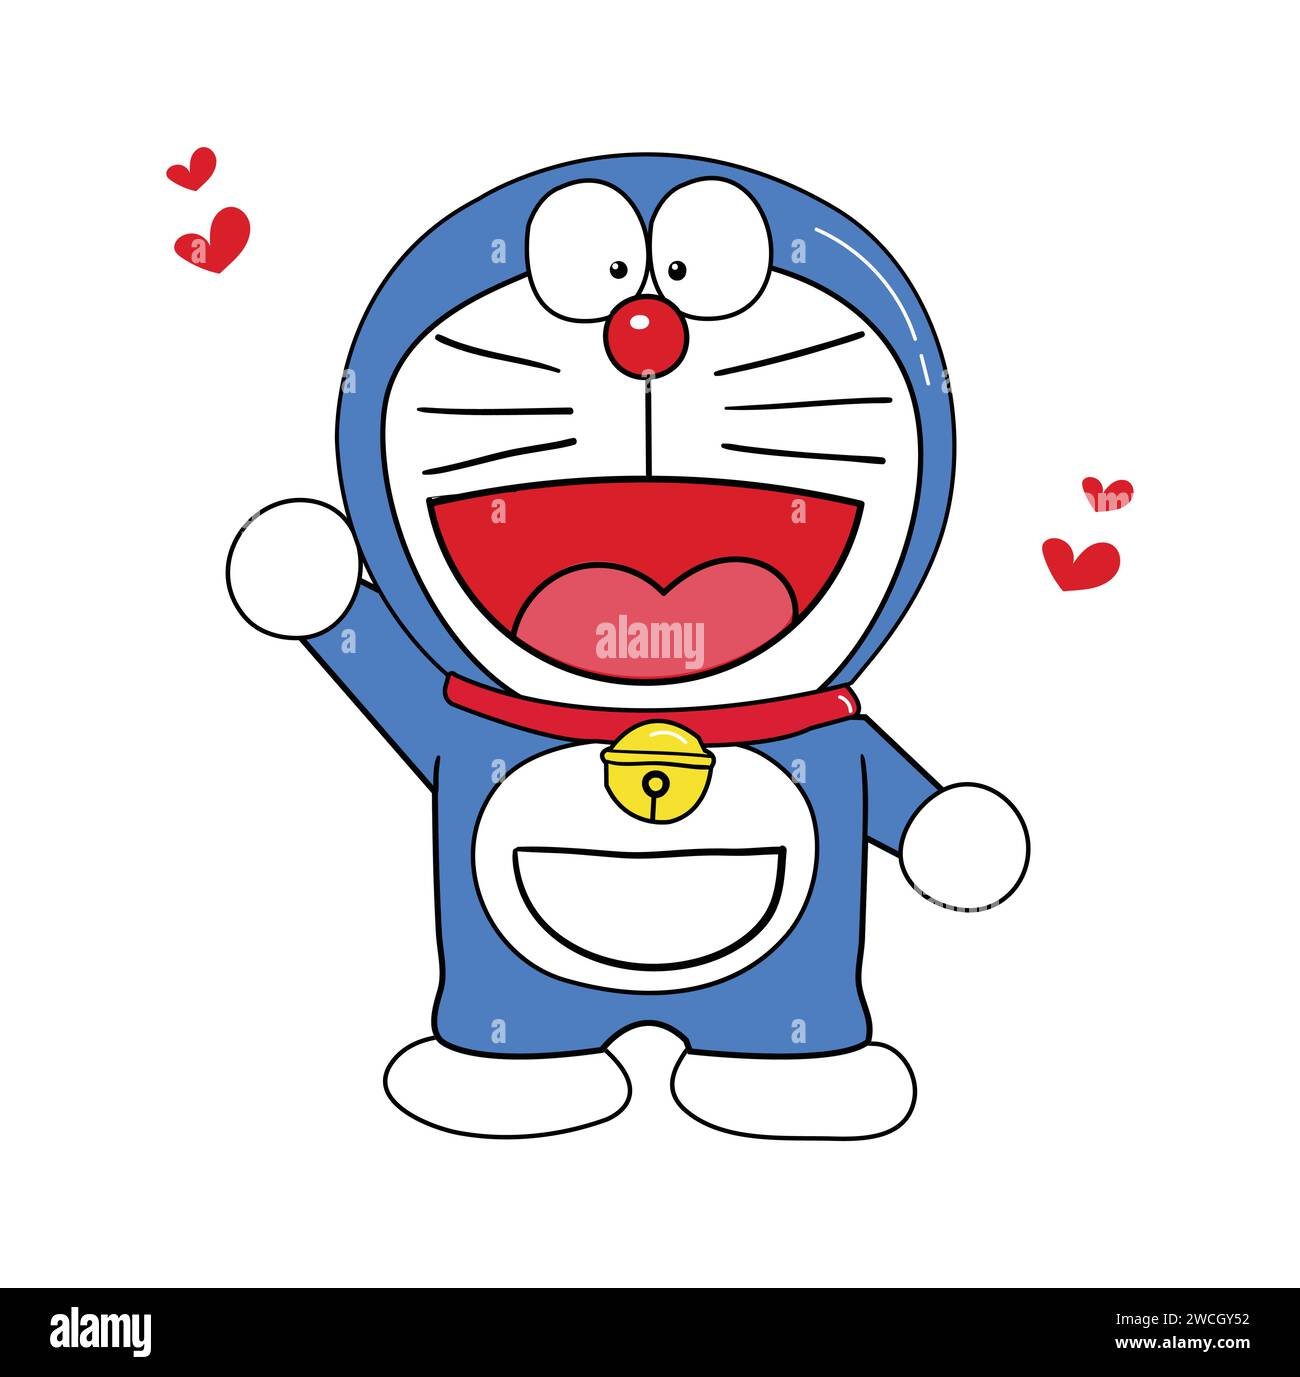


              IMAGE PROPERTIES
📄 File Name    : doraemon image.jpg
📐 Dimensions   : 1300 × 1377 pixels
🔢 Channels     : 3
💾 Data Type    : uint8
📦 File Size    : 82.55 KB
🎨 Image Mode   : RGB


In [7]:
# ============================================
# IMAGE PROPERTIES TOOL - GOOGLE COLAB
# Supports JPG, JPEG, PNG, BMP
# ============================================

!pip install -q pillow numpy

from google.colab import files
from PIL import Image
import numpy as np
import os


# --------------------------------------------
# File size formatter
# --------------------------------------------

def format_size(size_bytes):

    if size_bytes < 1024:
        return f"{size_bytes} B"

    elif size_bytes < 1024 ** 2:
        return f"{size_bytes / 1024:.2f} KB"

    elif size_bytes < 1024 ** 3:
        return f"{size_bytes / (1024 ** 2):.2f} MB"

    else:
        return f"{size_bytes / (1024 ** 3):.2f} GB"


# --------------------------------------------
# Number of channels
# --------------------------------------------

def get_channels(array):

    if array.ndim == 2:
        return 1

    elif array.ndim == 3:
        return array.shape[2]

    return "Unknown"


# --------------------------------------------
# Title
# --------------------------------------------

print("=" * 55)
print("          🖼️ IMAGE PROPERTIES TOOL")
print("=" * 55)

print()
print("Supported formats: JPG, JPEG, PNG, BMP")
print()


# --------------------------------------------
# Upload image
# --------------------------------------------

uploaded_files = files.upload()


# --------------------------------------------
# Check upload
# --------------------------------------------

if not uploaded_files:

    print("❌ No image selected.")

else:

    # Get first uploaded file
    file_name = list(uploaded_files.keys())[0]
    file_data = uploaded_files[file_name]

    # Check extension
    extension = os.path.splitext(file_name)[1].lower()

    supported_formats = [
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp"
    ]

    if extension not in supported_formats:

        print()
        print("❌ Unsupported image format.")
        print(
            "Please upload JPG, JPEG, PNG, or BMP."
        )

    else:

        try:

            # --------------------------------
            # Open image
            # --------------------------------

            image = Image.open(
                file_name
            )

            # --------------------------------
            # Convert to NumPy array
            # --------------------------------

            image_array = np.asarray(image)

            # --------------------------------
            # Image properties
            # --------------------------------

            width, height = image.size

            channels = get_channels(
                image_array
            )

            data_type = image_array.dtype

            file_size = len(file_data)

            image_mode = image.mode

            # --------------------------------
            # Display image
            # --------------------------------

            print()
            print("📷 Uploaded Image:")
            display(image)

            # --------------------------------
            # Display properties
            # --------------------------------

            print()
            print("=" * 55)
            print("              IMAGE PROPERTIES")
            print("=" * 55)

            print(
                f"📄 File Name    : {file_name}"
            )

            print(
                f"📐 Dimensions   : {width} × {height} pixels"
            )

            print(
                f"🔢 Channels     : {channels}"
            )

            print(
                f"💾 Data Type    : {data_type}"
            )

            print(
                f"📦 File Size    : {format_size(file_size)}"
            )

            print(
                f"🎨 Image Mode   : {image_mode}"
            )

            print("=" * 55)

        except Exception as error:

            print()
            print("❌ Error loading image:")
            print(error)


2. Create a Program that reads a colour image ,converts it to grayscale and saves both versions side by side for visual comparison.


       🖼️ COLOUR TO GRAYSCALE CONVERTER

Please upload a colour image...


Saving shuzikaa image.jpg to shuzikaa image.jpg


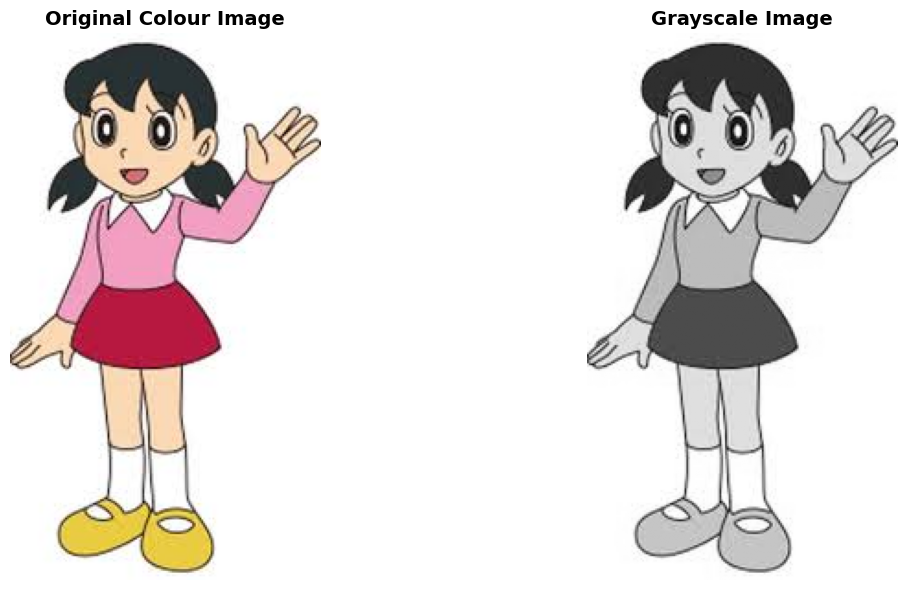


             ✅ CONVERSION COMPLETE
Original Image : shuzikaa image.jpg
Dimensions     : 169 × 298 pixels
Grayscale File : shuzikaa image_grayscale.png
Comparison File: shuzikaa image_comparison.png

⬇️ Downloading side-by-side comparison...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# ============================================
# COLOUR IMAGE TO GRAYSCALE
# SIDE-BY-SIDE VISUAL COMPARISON
# Google Colab / Jupyter compatible
# ============================================

!pip install -q pillow matplotlib

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import os


# ============================================
# Upload Image
# ============================================

print("=" * 60)
print("       🖼️ COLOUR TO GRAYSCALE CONVERTER")
print("=" * 60)
print()

print("Please upload a colour image...")
uploaded = files.upload()


# ============================================
# Check Upload
# ============================================

if not uploaded:

    print("❌ No image selected.")

else:

    # Get uploaded file name
    file_name = list(uploaded.keys())[0]

    try:

        # ========================================
        # Open original image
        # ========================================

        original = Image.open(file_name)

        # Convert to RGB to ensure colour image
        original = original.convert("RGB")


        # ========================================
        # Convert to Grayscale
        # ========================================

        grayscale = original.convert("L")


        # ========================================
        # Create side-by-side image
        # ========================================

        width, height = original.size

        comparison = Image.new(
            "RGB",
            (width * 2, height),
            "white"
        )

        # Paste original image on left
        comparison.paste(
            original,
            (0, 0)
        )

        # Convert grayscale to RGB
        grayscale_rgb = grayscale.convert("RGB")

        # Paste grayscale image on right
        comparison.paste(
            grayscale_rgb,
            (width, 0)
        )


        # ========================================
        # Save grayscale image
        # ========================================

        base_name = os.path.splitext(file_name)[0]

        grayscale_file = (
            base_name + "_grayscale.png"
        )

        comparison_file = (
            base_name + "_comparison.png"
        )

        grayscale.save(
            grayscale_file
        )

        comparison.save(
            comparison_file
        )


        # ========================================
        # Display Side-by-Side
        # ========================================

        plt.figure(
            figsize=(14, 6)
        )

        # Original
        plt.subplot(1, 2, 1)

        plt.imshow(original)

        plt.title(
            "Original Colour Image",
            fontsize=14,
            fontweight="bold"
        )

        plt.axis("off")


        # Grayscale
        plt.subplot(1, 2, 2)

        plt.imshow(
            grayscale,
            cmap="gray"
        )

        plt.title(
            "Grayscale Image",
            fontsize=14,
            fontweight="bold"
        )

        plt.axis("off")


        plt.tight_layout()

        plt.show()


        # ========================================
        # Success Information
        # ========================================

        print()
        print("=" * 60)
        print("             ✅ CONVERSION COMPLETE")
        print("=" * 60)

        print(
            f"Original Image : {file_name}"
        )

        print(
            f"Dimensions     : {width} × {height} pixels"
        )

        print(
            f"Grayscale File : {grayscale_file}"
        )

        print(
            f"Comparison File: {comparison_file}"
        )

        print("=" * 60)


        # ========================================
        # Download comparison image
        # ========================================

        print()
        print(
            "⬇️ Downloading side-by-side comparison..."
        )

        files.download(
            comparison_file
        )


    except Exception as error:

        print()
        print("❌ Error:")
        print(error)


3. Develop an image format converter that takes one input image and experts it simultaneously as JPG , PNG, AND BMP , then compares the resulting file sizes.

        🖼️ IMAGE FORMAT CONVERTER

Upload ONE image.
Supported input: JPG, JPEG, PNG, BMP



Saving close-up-of-blossoming-rose-flower-royalty-free-image-1580853844.avif to close-up-of-blossoming-rose-flower-royalty-free-image-1580853844.avif

✅ Input image loaded:
   close-up-of-blossoming-rose-flower-royalty-free-image-1580853844.avif
   Dimensions: 3655 × 3648
   Mode: RGB

              📊 FILE SIZE COMPARISON
JPG : 1.25 MB
PNG : 6.38 MB
BMP : 38.16 MB

🏆 Smallest file : JPG (1.25 MB)
📦 Largest file  : BMP (38.16 MB)


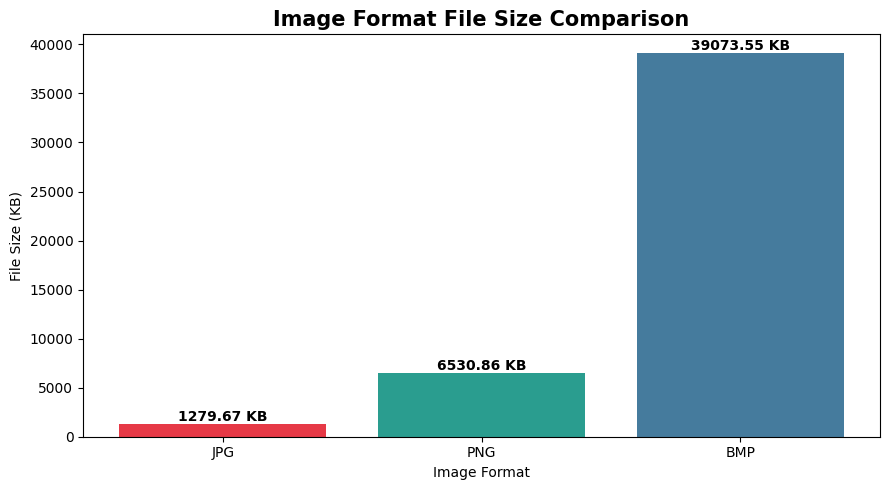


              💾 OUTPUT FILES
JPG : close-up-of-blossoming-rose-flower-royalty-free-image-1580853844_converted.jpg
PNG : close-up-of-blossoming-rose-flower-royalty-free-image-1580853844_converted.png
BMP : close-up-of-blossoming-rose-flower-royalty-free-image-1580853844_converted.bmp

⬇️ Downloading converted files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All three formats exported successfully!


In [9]:
# ============================================
# IMAGE FORMAT CONVERTER
# JPG + PNG + BMP
# WITH FILE SIZE COMPARISON
# Google Colab / Jupyter compatible
# ============================================

!pip install -q pillow matplotlib


from google.colab import files
from PIL import Image
import os
import matplotlib.pyplot as plt


# ============================================
# File Size Formatter
# ============================================

def format_size(size_bytes):

    if size_bytes < 1024:
        return f"{size_bytes} B"

    elif size_bytes < 1024 ** 2:
        return f"{size_bytes / 1024:.2f} KB"

    elif size_bytes < 1024 ** 3:
        return f"{size_bytes / (1024 ** 2):.2f} MB"

    else:
        return f"{size_bytes / (1024 ** 3):.2f} GB"


# ============================================
# Title
# ============================================

print("=" * 65)
print("        🖼️ IMAGE FORMAT CONVERTER")
print("=" * 65)

print()
print("Upload ONE image.")
print("Supported input: JPG, JPEG, PNG, BMP")
print()


# ============================================
# Upload Input Image
# ============================================

uploaded = files.upload()


if not uploaded:

    print("❌ No image selected.")

else:

    # Get uploaded filename
    input_name = list(uploaded.keys())[0]

    try:

        # ========================================
        # Open Input Image
        # ========================================

        image = Image.open(input_name)

        print()
        print("✅ Input image loaded:")
        print(f"   {input_name}")

        print(
            f"   Dimensions: {image.width} × {image.height}"
        )

        print(
            f"   Mode: {image.mode}"
        )


        # ========================================
        # Convert image to RGB
        # ========================================
        #
        # JPG does not support transparency.
        # Converting to RGB makes the output
        # compatible with JPG.
        #
        # PNG and BMP can also store RGB data.
        # ========================================

        rgb_image = image.convert("RGB")


        # ========================================
        # Generate output names
        # ========================================

        base_name = os.path.splitext(
            input_name
        )[0]

        jpg_file = (
            base_name + "_converted.jpg"
        )

        png_file = (
            base_name + "_converted.png"
        )

        bmp_file = (
            base_name + "_converted.bmp"
        )


        # ========================================
        # Export as JPG
        # ========================================

        rgb_image.save(
            jpg_file,
            format="JPEG",
            quality=95
        )


        # ========================================
        # Export as PNG
        # ========================================

        rgb_image.save(
            png_file,
            format="PNG"
        )


        # ========================================
        # Export as BMP
        # ========================================

        rgb_image.save(
            bmp_file,
            format="BMP"
        )


        # ========================================
        # Get File Sizes
        # ========================================

        jpg_size = os.path.getsize(
            jpg_file
        )

        png_size = os.path.getsize(
            png_file
        )

        bmp_size = os.path.getsize(
            bmp_file
        )


        # ========================================
        # Store results
        # ========================================

        results = {
            "JPG": jpg_size,
            "PNG": png_size,
            "BMP": bmp_size
        }


        # ========================================
        # Find smallest / largest
        # ========================================

        smallest_format = min(
            results,
            key=results.get
        )

        largest_format = max(
            results,
            key=results.get
        )


        # ========================================
        # Display File Size Comparison
        # ========================================

        print()
        print("=" * 65)
        print("              📊 FILE SIZE COMPARISON")
        print("=" * 65)

        print(
            f"JPG : {format_size(jpg_size)}"
        )

        print(
            f"PNG : {format_size(png_size)}"
        )

        print(
            f"BMP : {format_size(bmp_size)}"
        )

        print("=" * 65)


        # ========================================
        # Smallest / Largest
        # ========================================

        print()

        print(
            f"🏆 Smallest file : "
            f"{smallest_format} "
            f"({format_size(results[smallest_format])})"
        )

        print(
            f"📦 Largest file  : "
            f"{largest_format} "
            f"({format_size(results[largest_format])})"
        )


        # ========================================
        # Bar Chart
        # ========================================

        formats = list(results.keys())

        sizes_kb = [
            results[fmt] / 1024
            for fmt in formats
        ]

        colors = [
            "#e63946",
            "#2a9d8f",
            "#457b9d"
        ]


        plt.figure(
            figsize=(9, 5)
        )

        bars = plt.bar(
            formats,
            sizes_kb,
            color=colors
        )


        plt.title(
            "Image Format File Size Comparison",
            fontsize=15,
            fontweight="bold"
        )

        plt.xlabel(
            "Image Format"
        )

        plt.ylabel(
            "File Size (KB)"
        )


        # Show values on bars
        for bar, size in zip(
            bars,
            sizes_kb
        ):

            plt.text(
                bar.get_x()
                + bar.get_width() / 2,
                bar.get_height(),
                f"{size:.2f} KB",
                ha="center",
                va="bottom",
                fontweight="bold"
            )


        plt.tight_layout()
        plt.show()


        # ========================================
        # Output Files
        # ========================================

        print()
        print("=" * 65)
        print("              💾 OUTPUT FILES")
        print("=" * 65)

        print(
            f"JPG : {jpg_file}"
        )

        print(
            f"PNG : {png_file}"
        )

        print(
            f"BMP : {bmp_file}"
        )

        print("=" * 65)


        # ========================================
        # Download All Converted Files
        # ========================================

        print()
        print("⬇️ Downloading converted files...")


        files.download(
            jpg_file
        )

        files.download(
            png_file
        )

        files.download(
            bmp_file
        )


        print()
        print("✅ All three formats exported successfully!")


    except Exception as error:

        print()
        print("❌ Error converting image:")
        print(error)


4. Build a " photo negative " generator that computes and displays the complement of an  uploaded image.

              📷 PHOTO NEGATIVE GENERATOR

Upload an image to generate its photo negative.
Supported formats: JPG, JPEG, PNG, BMP



Saving Buterfly image.jpg to Buterfly image.jpg
✅ Image loaded successfully!
File       : Buterfly image.jpg
Dimensions : 680 × 451
Mode       : RGB


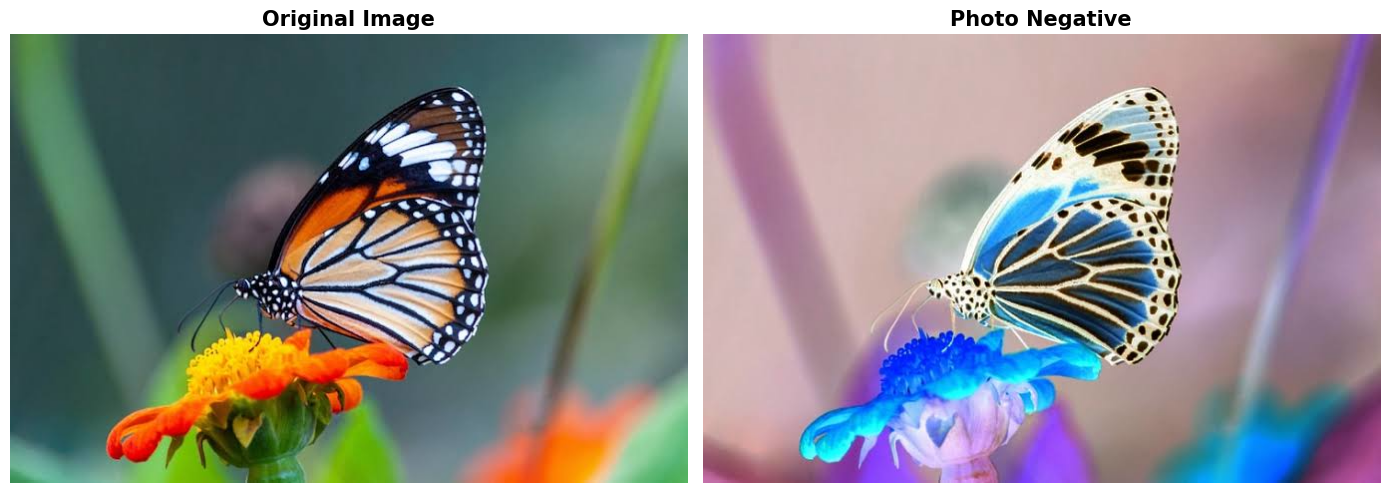


                 ✅ NEGATIVE GENERATED
Original file : Buterfly image.jpg
Negative file : Buterfly image_negative.png
Image size    : 680 × 451 pixels
Formula       : Negative = 255 - Original

⬇️ Downloading negative image...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Negative image saved and downloaded!


In [10]:
# ============================================================
# PHOTO NEGATIVE GENERATOR
# Computes and displays the complement of an uploaded image
# Google Colab / Jupyter compatible
# ============================================================

!pip install -q pillow matplotlib


from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os


# ============================================================
# Title
# ============================================================

print("=" * 65)
print("              📷 PHOTO NEGATIVE GENERATOR")
print("=" * 65)

print()
print("Upload an image to generate its photo negative.")
print("Supported formats: JPG, JPEG, PNG, BMP")
print()


# ============================================================
# Upload Image
# ============================================================

uploaded = files.upload()


if not uploaded:

    print("❌ No image selected.")

else:

    input_name = list(uploaded.keys())[0]

    try:

        # ====================================================
        # Open Image
        # ====================================================

        original = Image.open(input_name)

        print("✅ Image loaded successfully!")
        print(
            f"File       : {input_name}"
        )
        print(
            f"Dimensions : {original.width} × {original.height}"
        )
        print(
            f"Mode       : {original.mode}"
        )


        # ====================================================
        # Convert image to RGB
        # ====================================================

        rgb_image = original.convert("RGB")


        # ====================================================
        # Convert image to NumPy array
        # ====================================================

        image_array = np.array(
            rgb_image
        )


        # ====================================================
        # Calculate Photo Negative
        #
        # Complement formula:
        #
        # Negative = 255 - Original
        #
        # Example:
        # 0   -> 255
        # 50  -> 205
        # 100 -> 155
        # 255 -> 0
        # ====================================================

        negative_array = (
            255 - image_array
        )


        # ====================================================
        # Convert NumPy array back to image
        # ====================================================

        negative_image = Image.fromarray(
            negative_array.astype(np.uint8)
        )


        # ====================================================
        # Create output filename
        # ====================================================

        base_name = os.path.splitext(
            input_name
        )[0]

        negative_file = (
            base_name + "_negative.png"
        )


        # ====================================================
        # Save Negative Image
        # ====================================================

        negative_image.save(
            negative_file
        )


        # ====================================================
        # Display Original and Negative
        # ====================================================

        plt.figure(
            figsize=(14, 6)
        )


        # ----------------------------------------------------
        # Original Image
        # ----------------------------------------------------

        plt.subplot(
            1,
            2,
            1
        )

        plt.imshow(
            rgb_image
        )

        plt.title(
            "Original Image",
            fontsize=15,
            fontweight="bold"
        )

        plt.axis("off")


        # ----------------------------------------------------
        # Negative Image
        # ----------------------------------------------------

        plt.subplot(
            1,
            2,
            2
        )

        plt.imshow(
            negative_image
        )

        plt.title(
            "Photo Negative",
            fontsize=15,
            fontweight="bold"
        )

        plt.axis("off")


        plt.tight_layout()

        plt.show()


        # ====================================================
        # Display Information
        # ====================================================

        print()
        print("=" * 65)
        print("                 ✅ NEGATIVE GENERATED")
        print("=" * 65)

        print(
            f"Original file : {input_name}"
        )

        print(
            f"Negative file : {negative_file}"
        )

        print(
            f"Image size    : "
            f"{negative_image.width} × "
            f"{negative_image.height} pixels"
        )

        print(
            "Formula       : Negative = 255 - Original"
        )

        print("=" * 65)


        # ====================================================
        # Download Negative
        # ====================================================

        print()
        print("⬇️ Downloading negative image...")

        files.download(
            negative_file
        )

        print()
        print("✅ Negative image saved and downloaded!")


    except Exception as error:

        print()
        print("❌ Error processing image:")
        print(error)


5. Create  a batch image resizer that reads multiple images  from a folder and saves resized copies while preserving aspect ratio.

In [41]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError

# ============================================================
# SETTINGS
# ============================================================

INPUT_FOLDER = Path("/var/images ")
OUTPUT_FOLDER = Path("/var/images ")

# Maximum dimensions
MAX_WIDTH = 1200
MAX_HEIGHT = 1200

# Supported image formats
SUPPORTED_FORMATS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp",
    ".tif",
    ".tiff",
}


# ============================================================
# RESIZE FUNCTION
# ============================================================

def resize_image(input_path, output_path):
    try:
        with Image.open(input_path) as img:

            # Original size
            original_width, original_height = img.size

            # Create a copy so original image is never changed
            resized = img.copy()

            # Resize while preserving aspect ratio
            # thumbnail() will NOT enlarge smaller images
            resized.thumbnail(
                (MAX_WIDTH, MAX_HEIGHT),
                Image.Resampling.LANCZOS
            )

            # ------------------------------------------------
            # JPEG
            # ------------------------------------------------
            if output_path.suffix.lower() in {".jpg", ".jpeg"}:

                # JPEG does not support transparency
                if resized.mode in ("RGBA", "LA", "P"):
                    if resized.mode == "P":
                        resized = resized.convert("RGBA")

                    if resized.mode == "RGBA":
                        background = Image.new(
                            "RGB",
                            resized.size,
                            (255, 255, 255)
                        )

                        background.paste(
                            resized,
                            mask=resized.getchannel("A")
                        )

                        resized = background
                    else:
                        resized = resized.convert("RGB")

                else:
                    resized = resized.convert("RGB")

                resized.save(
                    output_path,
                    "JPEG",
                    quality=90,
                    optimize=True
                )

            # ------------------------------------------------
            # PNG
            # ------------------------------------------------
            elif output_path.suffix.lower() == ".png":

                resized.save(
                    output_path,
                    "PNG",
                    optimize=True
                )

            # ------------------------------------------------
            # WEBP
            # ------------------------------------------------
            elif output_path.suffix.lower() == ".webp":

                resized.save(
                    output_path,
                    "WEBP",
                    quality=90
                )

            # ------------------------------------------------
            # Other formats
            # ------------------------------------------------
            else:
                resized.save(output_path)

            print(
                f"SUCCESS: {input_path.name} | "
                f"{original_width}x{original_height} -> "
                f"{resized.width}x{resized.height}"
            )

            return True

    except UnidentifiedImageError:
        print(f"ERROR: Not a valid image: {input_path.name}")
        return False

    except Exception as e:
        print(f"ERROR: {input_path.name}")
        print(f"       {e}")
        return False


# ============================================================
# MAIN FUNCTION
# ============================================================

def main():

    print("=" * 60)
    print("       BATCH IMAGE RESIZER")
    print("=" * 60)

    # Create input folder if it doesn't exist
    if not INPUT_FOLDER.exists():
        INPUT_FOLDER.mkdir(parents=True)

        print()
        print(f"Input folder created: {INPUT_FOLDER}")
        print("Please put your images inside the 'images' folder.")
        print()
        return

    # Create output folder
    OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

    # Find images
    image_files = [
        file
        for file in INPUT_FOLDER.iterdir()
        if file.is_file()
        and file.suffix.lower() in SUPPORTED_FORMATS
    ]

    # No images found
    if not image_files:
        print()
        print("No images found.")
        print()
        print(f"Put images inside: {INPUT_FOLDER.resolve()}")
        print()
        print("Supported formats:")
        print(", ".join(sorted(SUPPORTED_FORMATS)))
        return

    print()
    print(f"Input folder : {INPUT_FOLDER.resolve()}")
    print(f"Output folder: {OUTPUT_FOLDER.resolve()}")
    print(f"Maximum size : {MAX_WIDTH} x {MAX_HEIGHT}")
    print()
    print(f"Found {len(image_files)} image(s).")
    print("-" * 60)

    success_count = 0
    error_count = 0

    # Process every image
    for image_file in image_files:

        output_file = OUTPUT_FOLDER / image_file.name

        if resize_image(image_file, output_file):
            success_count += 1
        else:
            error_count += 1

    # Final result
    print("-" * 60)
    print()
    print("DONE!")
    print(f"Successful: {success_count}")
    print(f"Failed    : {error_count}")
    print()
    print(f"Resized images are here:")
    print(OUTPUT_FOLDER.resolve())
    print()


# ============================================================
# START PROGRAM
# ============================================================

if __name__ == "__main__":
    main()


       BATCH IMAGE RESIZER

Input folder : /var/images 
Output folder: /var/images 
Maximum size : 1200 x 1200

Found 4 image(s).
------------------------------------------------------------
SUCCESS: shuzikaa image.jpg | 169x298 -> 169x298
SUCCESS: doraemon image.jpg | 1300x1377 -> 1133x1200
SUCCESS: images.jpg | 547x365 -> 547x365
SUCCESS: ballon image.jpg | 582x343 -> 582x343
------------------------------------------------------------

DONE!
Successful: 4
Failed    : 0

Resized images are here:
/var/images 



6. Develop a program that crops  a user specified region of interest (ROI) from an image and saves it as a separate file.

📷 Upload the image:


Saving images.jpg to images (1).jpg

✅ Image loaded successfully
Image width  : 547 pixels
Image height : 365 pixels

ENTER ROI DETAILS

Coordinate system:

(0,0) --------------------> X
  |
  |
  |
  |
  v
  Y

Enter the TOP-LEFT corner of the ROI,
followed by its width and height.

Enter X coordinate: 20
Enter Y coordinate: 20
Enter ROI width: 500
Enter ROI height: 300

✅ ROI coordinates:
Left   : 20
Top    : 20
Right  : 520
Bottom : 320

✅ ROI cropped successfully!
Output file: cropped_ROI.png
Cropped size: 500 x 300 pixels

🖼️ ORIGINAL IMAGE


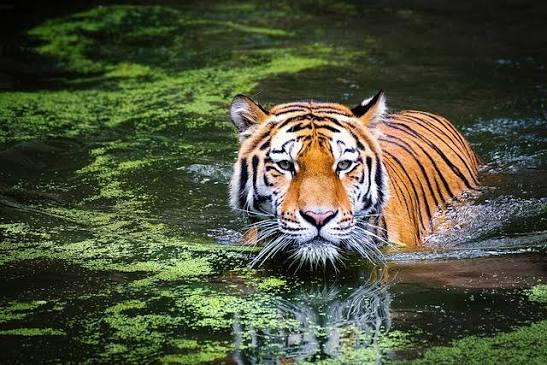


✂️ CROPPED ROI


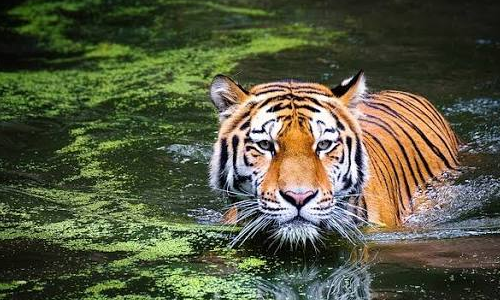


⬇️ Downloading cropped ROI...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ============================================================
# GOOGLE COLAB - ROI IMAGE CROPPING UTILITY
# ============================================================

from PIL import Image
from google.colab import files
import os


# ============================================================
# 1. UPLOAD IMAGE
# ============================================================

print("📷 Upload the image:")

uploaded = files.upload()

if not uploaded:
    raise ValueError("No image was uploaded.")

input_path = next(iter(uploaded))

# Open image
image = Image.open(input_path)

print("\n✅ Image loaded successfully")
print(f"Image width  : {image.width} pixels")
print(f"Image height : {image.height} pixels")


# ============================================================
# 2. GET ROI COORDINATES
# ============================================================

print("\n" + "=" * 50)
print("ENTER ROI DETAILS")
print("=" * 50)

print("""
Coordinate system:

(0,0) --------------------> X
  |
  |
  |
  |
  v
  Y

Enter the TOP-LEFT corner of the ROI,
followed by its width and height.
""")


x = int(input("Enter X coordinate: "))
y = int(input("Enter Y coordinate: "))

roi_width = int(
    input("Enter ROI width: ")
)

roi_height = int(
    input("Enter ROI height: ")
)


# ============================================================
# 3. VALIDATE ROI
# ============================================================

if x < 0 or y < 0:
    raise ValueError(
        "X and Y coordinates cannot be negative."
    )

if roi_width <= 0 or roi_height <= 0:
    raise ValueError(
        "ROI width and height must be greater than 0."
    )

if x + roi_width > image.width:
    raise ValueError(
        f"ROI exceeds image width. "
        f"Maximum allowed width from X={x} is {image.width - x}."
    )

if y + roi_height > image.height:
    raise ValueError(
        f"ROI exceeds image height. "
        f"Maximum allowed height from Y={y} is {image.height - y}."
    )


# ============================================================
# 4. DEFINE ROI
# ============================================================

left = x
top = y
right = x + roi_width
bottom = y + roi_height

roi_box = (
    left,
    top,
    right,
    bottom
)

print("\n✅ ROI coordinates:")
print(f"Left   : {left}")
print(f"Top    : {top}")
print(f"Right  : {right}")
print(f"Bottom : {bottom}")


# ============================================================
# 5. CROP IMAGE
# ============================================================

cropped_image = image.crop(roi_box)


# ============================================================
# 6. SAVE CROPPED IMAGE
# ============================================================

output_path = "cropped_ROI.png"

cropped_image.save(
    output_path
)

print("\n✅ ROI cropped successfully!")
print(f"Output file: {output_path}")
print(
    f"Cropped size: "
    f"{cropped_image.width} x {cropped_image.height} pixels"
)


# ============================================================
# 7. DISPLAY ORIGINAL AND CROPPED IMAGE
# ============================================================

print("\n🖼️ ORIGINAL IMAGE")
display(image)

print("\n✂️ CROPPED ROI")
display(cropped_image)


# ============================================================
# 8. DOWNLOAD CROPPED IMAGE
# ============================================================

print("\n⬇️ Downloading cropped ROI...")

files.download(output_path)


7. Build a tool that splits an image into  its individual Red , Green ,and blue channels then  reconstruct it and verifies pixel level  accuracy.


📷 Upload the image:


Saving download.png to download.png

✅ Image loaded successfully
Image size: 225 x 225
Total pixels: 50625

🔴 Splitting RGB channels...
✅ Red channel saved
✅ Green channel saved
✅ Blue channel saved

🔧 Reconstructing image from RGB channels...
✅ Image reconstructed successfully

🔍 Verifying pixel-level accuracy...


           PIXEL-LEVEL VERIFICATION REPORT

Image dimensions:
  Width  : 225
  Height : 225

Total pixels:
  50,625

Total RGB values:
  151,875

Pixel comparison:
  Matching pixels : 50,625
  Different pixels: 0
  Pixel accuracy  : 100.0000000000%

RGB value comparison:
  Matching values : 151,875
  Different values: 0
  Value accuracy  : 100.0000000000%

Maximum RGB difference:
  0

Total absolute difference:
  0

Exact reconstruction:
  ✅ PASS
  Original and reconstructed images are EXACTLY identical.


🖼️ ORIGINAL IMAGE


/tmp/ipykernel_3719/2042146805.py:171: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  difference_image = Image.fromarray(


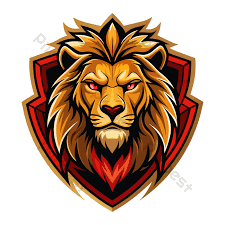


🔴 RED CHANNEL


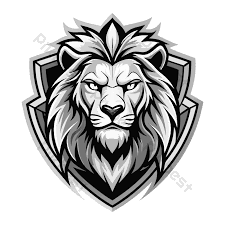


🟢 GREEN CHANNEL


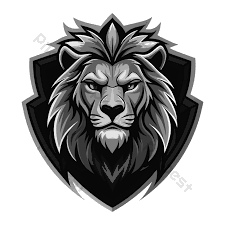


🔵 BLUE CHANNEL


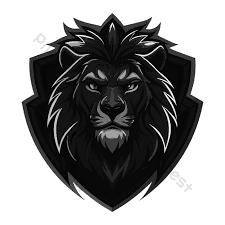


🔧 RECONSTRUCTED IMAGE


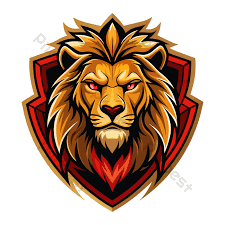


🔍 DIFFERENCE IMAGE


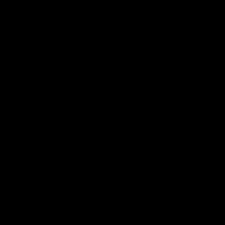


📦 All results packaged into:
   rgb_channel_results.zip

⬇️ Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# ============================================================
# GOOGLE COLAB
# RGB CHANNEL SPLITTER + RECONSTRUCTOR + PIXEL VERIFICATION
# ============================================================

from PIL import Image
from google.colab import files
import numpy as np
import os
import zipfile


# ============================================================
# 1. UPLOAD IMAGE
# ============================================================

print("📷 Upload the image:")

uploaded = files.upload()

if not uploaded:
    raise ValueError("No image was uploaded.")

input_path = next(iter(uploaded))

# Open image and convert to RGB
original = Image.open(input_path).convert("RGB")

print("\n✅ Image loaded successfully")
print(f"Image size: {original.width} x {original.height}")
print(f"Total pixels: {original.width * original.height}")


# ============================================================
# 2. CREATE OUTPUT DIRECTORY
# ============================================================

output_dir = "rgb_channel_output"

os.makedirs(output_dir, exist_ok=True)


# ============================================================
# 3. SPLIT RGB CHANNELS
# ============================================================

print("\n🔴 Splitting RGB channels...")

red, green, blue = original.split()

# Save individual channels
red_path = os.path.join(output_dir, "red_channel.png")
green_path = os.path.join(output_dir, "green_channel.png")
blue_path = os.path.join(output_dir, "blue_channel.png")

red.save(red_path)
green.save(green_path)
blue.save(blue_path)

print("✅ Red channel saved")
print("✅ Green channel saved")
print("✅ Blue channel saved")


# ============================================================
# 4. RECONSTRUCT IMAGE
# ============================================================

print("\n🔧 Reconstructing image from RGB channels...")

reconstructed = Image.merge(
    "RGB",
    (red, green, blue)
)

reconstructed_path = os.path.join(
    output_dir,
    "reconstructed_image.png"
)

reconstructed.save(reconstructed_path)

print("✅ Image reconstructed successfully")


# ============================================================
# 5. CONVERT IMAGES TO NUMPY ARRAYS
# ============================================================

original_array = np.array(original, dtype=np.uint8)

reconstructed_array = np.array(
    reconstructed,
    dtype=np.uint8
)


# ============================================================
# 6. PIXEL-LEVEL COMPARISON
# ============================================================

print("\n🔍 Verifying pixel-level accuracy...")

# Compare every RGB value
pixel_match = (
    original_array == reconstructed_array
)

# Check whether every channel of every pixel matches
exact_match = np.all(pixel_match)


# ============================================================
# 7. CALCULATE DIFFERENCES
# ============================================================

# Absolute difference
difference = np.abs(
    original_array.astype(np.int16)
    -
    reconstructed_array.astype(np.int16)
)

max_difference = difference.max()
total_difference = difference.sum()
different_values = np.count_nonzero(difference)

total_values = original_array.size

matching_values = total_values - different_values

accuracy = (
    matching_values / total_values
) * 100


# ============================================================
# 8. PIXEL COUNT VERIFICATION
# ============================================================

# A pixel is considered different if ANY RGB channel differs
different_pixels = np.any(
    original_array != reconstructed_array,
    axis=2
)

different_pixel_count = np.count_nonzero(
    different_pixels
)

total_pixels = original_array.shape[0] * original_array.shape[1]

matching_pixels = total_pixels - different_pixel_count

pixel_accuracy = (
    matching_pixels / total_pixels
) * 100


# ============================================================
# 9. CREATE DIFFERENCE IMAGE
# ============================================================

# Highlight differences
difference_visual = np.clip(
    difference * 10,
    0,
    255
).astype(np.uint8)

difference_image = Image.fromarray(
    difference_visual,
    "RGB"
)

difference_path = os.path.join(
    output_dir,
    "difference_image.png"
)

difference_image.save(difference_path)


# ============================================================
# 10. PRINT VERIFICATION REPORT
# ============================================================

print("\n")
print("=" * 55)
print("           PIXEL-LEVEL VERIFICATION REPORT")
print("=" * 55)

print(f"\nImage dimensions:")
print(f"  Width  : {original.width}")
print(f"  Height : {original.height}")

print(f"\nTotal pixels:")
print(f"  {total_pixels:,}")

print(f"\nTotal RGB values:")
print(f"  {total_values:,}")

print("\nPixel comparison:")
print(f"  Matching pixels : {matching_pixels:,}")
print(f"  Different pixels: {different_pixel_count:,}")
print(f"  Pixel accuracy  : {pixel_accuracy:.10f}%")

print("\nRGB value comparison:")
print(f"  Matching values : {matching_values:,}")
print(f"  Different values: {different_values:,}")
print(f"  Value accuracy  : {accuracy:.10f}%")

print("\nMaximum RGB difference:")
print(f"  {max_difference}")

print("\nTotal absolute difference:")
print(f"  {total_difference:,}")

print("\nExact reconstruction:")
if exact_match:
    print("  ✅ PASS")
    print("  Original and reconstructed images are EXACTLY identical.")
else:
    print("  ❌ FAIL")
    print("  Some pixel/channel values are different.")

print("\n" + "=" * 55)


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

print("\n🖼️ ORIGINAL IMAGE")
display(original)

print("\n🔴 RED CHANNEL")
display(red)

print("\n🟢 GREEN CHANNEL")
display(green)

print("\n🔵 BLUE CHANNEL")
display(blue)

print("\n🔧 RECONSTRUCTED IMAGE")
display(reconstructed)

print("\n🔍 DIFFERENCE IMAGE")
display(difference_image)


# ============================================================
# 12. CREATE ZIP FILE
# ============================================================

zip_path = "rgb_channel_results.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    zip_file.write(
        red_path,
        "red_channel.png"
    )

    zip_file.write(
        green_path,
        "green_channel.png"
    )

    zip_file.write(
        blue_path,
        "blue_channel.png"
    )

    zip_file.write(
        reconstructed_path,
        "reconstructed_image.png"
    )

    zip_file.write(
        difference_path,
        "difference_image.png"
    )


# ============================================================
# 13. DOWNLOAD ALL RESULTS
# ============================================================

print("\n📦 All results packaged into:")
print(f"   {zip_path}")

print("\n⬇️ Downloading...")

files.download(zip_path)


8. Create a watermarking Utility that overlays a logo or text on an image and saves  the  watermarked ouput.

📷 Apni original image upload karein:


Saving shuzikaa image.jpg to shuzikaa image.jpg
✅ Image loaded: 169 x 298

🎨 Ab apna LOGO upload karein:
Recommended format: PNG with transparent background


Saving download.png to download (1).png
✅ Logo loaded: 225 x 225

Logo size choose karein.
Example: 20 = small, 40 = medium, 60 = large
Logo width (% of original image width): 50

Opacity choose karein.
50 = transparent
128 = medium
255 = fully visible
Logo opacity (0-255): 224

📍 Logo position: CENTER
X: 42
Y: 107

✅ WATERMARKING COMPLETE!
Output file: watermarked_output.png

🖼️ Watermarked Image:


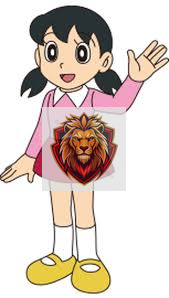


⬇️ Downloading output...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# ============================================================
# GOOGLE COLAB - CENTER LOGO WATERMARKING UTILITY
# ============================================================

from PIL import Image
from google.colab import files
import os

# ------------------------------------------------------------
# 1. Upload Main Image
# ------------------------------------------------------------

print("📷 Apni original image upload karein:")

uploaded = files.upload()

if not uploaded:
    raise ValueError("Image upload nahi hui.")

image_path = next(iter(uploaded))

# Open image
image = Image.open(image_path).convert("RGBA")

print(f"✅ Image loaded: {image.width} x {image.height}")


# ------------------------------------------------------------
# 2. Upload Logo
# ------------------------------------------------------------

print("\n🎨 Ab apna LOGO upload karein:")
print("Recommended format: PNG with transparent background")

uploaded_logo = files.upload()

if not uploaded_logo:
    raise ValueError("Logo upload nahi hua.")

logo_path = next(iter(uploaded_logo))

# Open logo
logo = Image.open(logo_path).convert("RGBA")

print(f"✅ Logo loaded: {logo.width} x {logo.height}")


# ------------------------------------------------------------
# 3. Logo Size
# ------------------------------------------------------------

print("\nLogo size choose karein.")
print("Example: 20 = small, 40 = medium, 60 = large")

logo_percentage = float(
    input("Logo width (% of original image width): ")
)

# Calculate logo width
target_width = int(
    image.width * logo_percentage / 100
)

# Maintain logo aspect ratio
aspect_ratio = logo.height / logo.width

target_height = int(
    target_width * aspect_ratio
)

# Resize logo
logo = logo.resize(
    (target_width, target_height),
    Image.Resampling.LANCZOS
)


# ------------------------------------------------------------
# 4. Logo Opacity
# ------------------------------------------------------------

print("\nOpacity choose karein.")
print("50 = transparent")
print("128 = medium")
print("255 = fully visible")

opacity = int(
    input("Logo opacity (0-255): ")
)

# Make sure opacity is valid
opacity = max(0, min(255, opacity))


# ------------------------------------------------------------
# 5. Apply Opacity
# ------------------------------------------------------------

alpha = logo.getchannel("A")

alpha = alpha.point(
    lambda p: int(p * opacity / 255)
)

logo.putalpha(alpha)


# ------------------------------------------------------------
# 6. EXACT CENTER POSITION
# ------------------------------------------------------------

x = (image.width - logo.width) // 2
y = (image.height - logo.height) // 2

print(f"\n📍 Logo position: CENTER")
print(f"X: {x}")
print(f"Y: {y}")


# ------------------------------------------------------------
# 7. Create Transparent Layer
# ------------------------------------------------------------

watermark_layer = Image.new(
    "RGBA",
    image.size,
    (0, 0, 0, 0)
)


# ------------------------------------------------------------
# 8. Put Logo in Center
# ------------------------------------------------------------

watermark_layer.paste(
    logo,
    (x, y),
    logo
)


# ------------------------------------------------------------
# 9. Combine Image + Logo
# ------------------------------------------------------------

result = Image.alpha_composite(
    image,
    watermark_layer
)


# ------------------------------------------------------------
# 10. Save Output
# ------------------------------------------------------------

output_path = "watermarked_output.png"

result.save(
    output_path,
    "PNG"
)

print("\n========================================")
print("✅ WATERMARKING COMPLETE!")
print("========================================")
print(f"Output file: {output_path}")


# ------------------------------------------------------------
# 11. Display Result
# ------------------------------------------------------------

print("\n🖼️ Watermarked Image:")

display(result)


# ------------------------------------------------------------
# 12. Download Output
# ------------------------------------------------------------

print("\n⬇️ Downloading output...")

files.download(output_path)
